# Case study 5 — Transport vs local contributions (PM2.5 at MY1)

Notebook 04 adds HYSPLIT back-trajectory features to the model so that
normalisation also averages over long-range transport. This notebook asks the
follow-up question: **how much of the PM$_{2.5}$ signal is local weather and how
much is the air mass arriving from elsewhere?**

`decom_met` answers it with `groups`: the local meteorology and the trajectory
features are attributed as two units, with the Shapley split -- the average of
each group's effect over both orders in which it can be fixed -- so the answer
does not depend on which group is fixed first. Three points:

1. the grouped decomposition itself;
2. why neither a fixed order nor the two-model difference of notebook 04 is used;
3. a *reference air mass* (`resample_pools`), which turns the transport term
   from an anomaly into a contribution relative to clean air.

Bundled data: `load_my1_pm25()` (hourly PM$_{2.5}$ + ERA5 met, Jan–Aug 2020) and
`load_traj_my1()` (6-hourly 72-h trajectory features).

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "4")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import normet as nm

panel = nm.datasets.load_my1_pm25().rename(columns={"pm25": "value"})
traj = nm.datasets.load_traj_my1()

MET_COLS = ["ws_era5", "wd_era5", "temp_era5", "blh", "sp", "ssrd", "tcc", "tp"]
TRAJ_COLS = [c for c in traj.columns if c.startswith("traj_")]
TIME_VARS = ["date_unix", "day_julian", "weekday", "hour"]
PREDS = MET_COLS + TRAJ_COLS + TIME_VARS
GROUPS = {"local": MET_COLS, "transport": TRAJ_COLS}
SEED, NS = 7654321, 200

# Each hour takes the latest trajectory that has already arrived (at most 6 h
# old): a "nearest" join would hand the hours before a release the air that
# has not reached the receptor yet.
hours = pd.DataFrame({"date": pd.date_range(traj["date"].min(), traj["date"].max(), freq="1h")})
traj_h = pd.merge_asof(hours, traj.sort_values("date"), on="date",
                       direction="backward", tolerance=pd.Timedelta("6h"))
base = panel.loc[panel["value"].notna(), ["date", "value"] + MET_COLS]
base = base.merge(traj_h[["date"] + TRAJ_COLS], on="date", how="left")
for c in TRAJ_COLS:
    base[c] = base[c].fillna(traj_h[c].mean())
base = nm.add_date_variables(base).sort_values("date").reset_index(drop=True)
print(f"{len(base)} hourly rows, {len(MET_COLS)} local-met and {len(TRAJ_COLS)} trajectory features")

5715 hourly rows, 8 local-met and 11 trajectory features


## 1. One transport-aware model, evaluated on a blocked split

Trajectories released every 6 h are constant across the hours of a release
window, so under a random train/test split a tree model can use them as a time
fingerprint and memorise neighbouring hours. A blocked split (`month_ts`: a
contiguous block held out in every month) is the honest check.

In [2]:
cfg = {"n_trials": 8, "cv_folds": 3, "nrounds": 300, "early_stopping_rounds": 15}
prep, model = nm.build_model(base, target="value", backend="lightgbm", covariates=PREDS,
                             split_method="month_ts", train_fraction=0.75, model_config=cfg,
                             seed=SEED, verbose=False, n_cores=4)
stats = nm.modStats(prep, model)
stats.loc[:, ["set", "R2", "RMSE"]].round(3)

,set,R2,RMSE
0,training,0.966,1.460
1,testing,0.493,6.623
2,all,0.817,3.546


## 2. Grouped attribution: local weather vs transport

`emi_total` is the normalised series with *every* meteorological and
trajectory feature resampled. The prediction minus `emi_total` is split into a
`local` and a `transport` column; together with the model residual they add
back up to `met_total` exactly.

In [3]:
res = nm.decompose(method="meteorology", df=base, model=model, covariates=PREDS,
                   groups=GROUPS, n_samples=NS, seed=SEED, n_cores=4)

closes = np.allclose(res["local"] + res["transport"] + res["met_base"] + res["met_noise"],
                     res["met_total"])
print("local + transport + met_base + met_noise == met_total:", closes)
res[["observed", "emi_total", "local", "transport"]].describe().loc[["mean", "std"]].round(2)

local + transport + met_base + met_noise == met_total: True


,observed,emi_total,local,transport
mean,9.01,8.91,0.08,-0.03
std,8.29,2.26,3.41,4.84


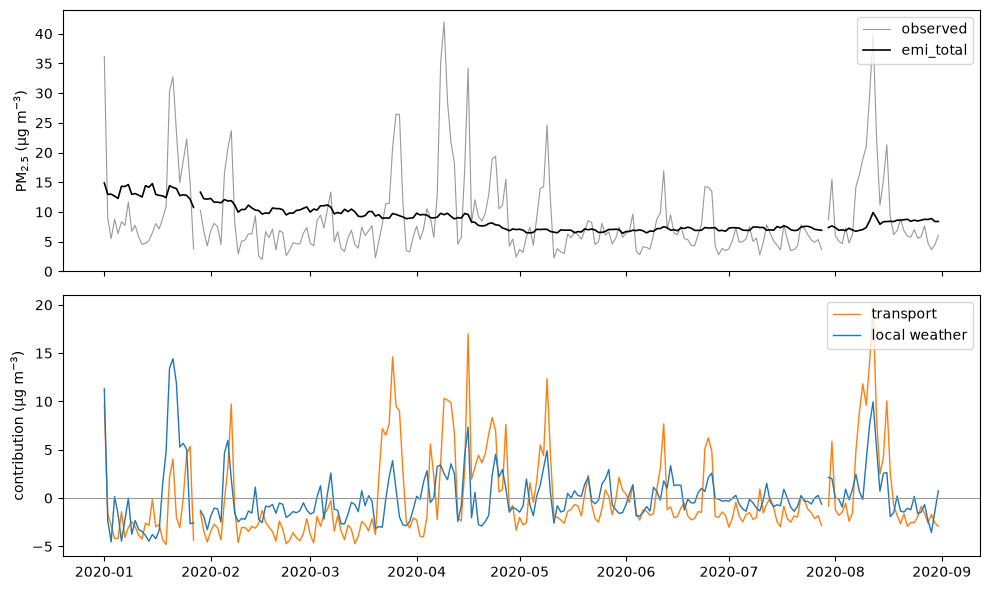

In [4]:
daily = res[["observed", "emi_total", "local", "transport"]].resample("D").mean()
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(daily.index, daily["observed"], color="0.6", lw=0.8, label="observed")
axes[0].plot(daily.index, daily["emi_total"], color="k", lw=1.2, label="emi_total")
axes[0].set_ylabel("PM$_{2.5}$ (µg m$^{-3}$)")
axes[0].legend(loc="upper right")
axes[1].plot(daily.index, daily["transport"], color="tab:orange", lw=1.0, label="transport")
axes[1].plot(daily.index, daily["local"], color="tab:blue", lw=1.0, label="local weather")
axes[1].axhline(0, color="0.6", lw=0.8)
axes[1].set_ylabel("contribution (µg m$^{-3}$)")
axes[1].legend(loc="upper right")
plt.tight_layout()

Both columns are measured against `emi_total`, i.e. against the **average**
conditions in the record -- the average local weather and the average air mass.
Over the record they are therefore anomalies with a mean near zero: they say
when and by how much the arriving air was dirtier or cleaner than usual, not
how much of the PM$_{2.5}$ came from outside. Section 4 changes the reference.

## 3. Why not a fixed order, or two models?

**A fixed order.** The sequential attribution fixes one group, then the other,
and credits each with its step's change -- so their interaction goes to
whichever comes second. With two groups the Shapley split is exactly the
average of the two orders:

In [5]:
kw = dict(method="meteorology", df=base, model=model, covariates=PREDS,
          attribution="sequential", n_samples=NS, seed=SEED, n_cores=4)
transport_first = nm.decompose(groups={"transport": TRAJ_COLS, "local": MET_COLS}, **kw)
local_first = nm.decompose(groups=GROUPS, **kw)

orders = pd.DataFrame({
    "transport fixed first": transport_first["transport"],
    "transport fixed second": local_first["transport"],
    "Shapley": res["transport"],
})
print("Shapley == mean of the two orders:",
      np.allclose(res["transport"], 0.5 * (transport_first["transport"] + local_first["transport"])))
orders.agg(["mean", "std"]).round(2)

Shapley == mean of the two orders: True


,transport fixed first,transport fixed second,Shapley
mean,-0.05,-0.00,-0.03
std,4.54,5.32,4.84


**Two models.** Notebook 04 estimates the transport contribution as the
difference between a local-only model's normalised series and the
transport-aware model's. The local-only model never sees the trajectories, so
the only transport signal its normalised series can keep is whatever its time
variables memorised -- a fraction of the effect, mixed with the differences
between two separately fitted models:

correlation: 0.59; amplitude ratio (sd): 0.40


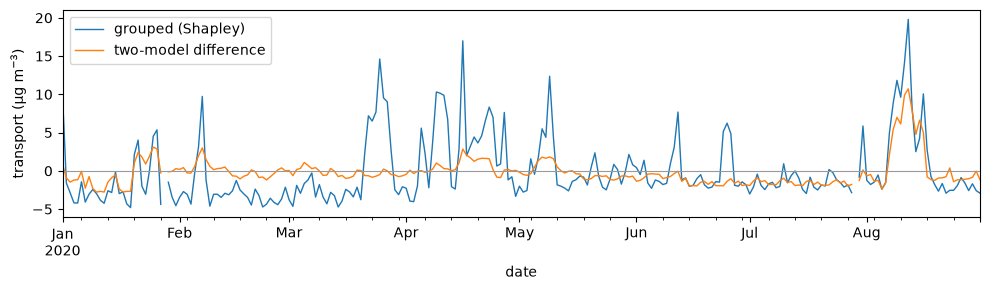

In [6]:
local_preds = MET_COLS + TIME_VARS
_, model_local = nm.build_model(base, target="value", backend="lightgbm", covariates=local_preds,
                                split_method="month_ts", train_fraction=0.75, model_config=cfg,
                                seed=SEED, verbose=False, n_cores=4)
dw_local = nm.normalise(base, model_local, covariates=local_preds, variables_resample=MET_COLS,
                        n_samples=NS, seed=SEED, n_cores=4)
two_model = dw_local["normalised"].reindex(res.index) - res["emi_total"]

cmp = pd.DataFrame({"grouped (Shapley)": res["transport"], "two-model difference": two_model})
print(f"correlation: {cmp.corr().iloc[0, 1]:.2f}; "
      f"amplitude ratio (sd): {two_model.std() / res['transport'].std():.2f}")
cmp.resample("D").mean().plot(figsize=(10, 3), lw=1)
plt.axhline(0, color="0.6", lw=0.8)
plt.ylabel("transport (µg m$^{-3}$)")
plt.tight_layout()

## 4. A reference air mass: transport as a contribution

To ask how much PM$_{2.5}$ the arriving air *added*, measure it against a
reference instead of against the average air mass. `resample_pools` draws the
trajectory features from a pool of their own -- here the hours whose back
trajectories spent more than 80% of their time over the Atlantic box -- while
the local weather is still drawn from the whole record.

`emi_total` then becomes the level under clean Atlantic air with average local
weather, and `transport` the change from that air to the air that actually
arrived. The reference is a choice and should be stated with the result.

In [7]:
clean = base[base["traj_resid_atlantic"] > 0.8]
print(f"reference pool: {len(clean)} of {len(base)} hours; observed PM2.5 there "
      f"{clean['value'].mean():.1f} vs {base['value'].mean():.1f} µg/m3 overall")

ref = nm.decompose(method="meteorology", df=base, model=model, covariates=PREDS, groups=GROUPS,
                   resample_pools={"transport": clean[TRAJ_COLS]},
                   n_samples=NS, seed=SEED, n_cores=4)

summary = pd.DataFrame({
    "average air mass": [res["emi_total"].mean(), res["transport"].mean(),
                         (res["transport"] > 0).mean() * 100],
    "clean Atlantic reference": [ref["emi_total"].mean(), ref["transport"].mean(),
                                 (ref["transport"] > 0).mean() * 100],
}, index=["emi_total mean (µg/m3)", "transport mean (µg/m3)", "hours with transport > 0 (%)"])
summary.round(2)

reference pool: 855 of 5715 hours; observed PM2.5 there 5.3 vs 9.0 µg/m3 overall


,average air mass,clean Atlantic reference
emi_total mean (µg/m3),8.91,6.16
transport mean (µg/m3),-0.03,2.70
hours with transport > 0 (%),30.64,67.86


,observed,emi_total,transport
date,,,
2020-08-12,40.0,7.2,23.1
2020-04-16,34.2,6.0,21.4
2020-03-25,20.9,5.9,18.6
2020-08-11,29.8,5.9,17.3
2020-05-09,24.6,4.7,15.5


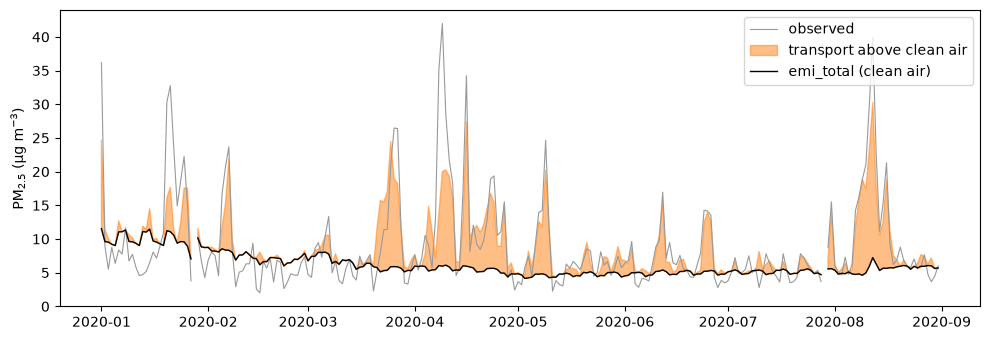

In [8]:
daily_ref = ref[["observed", "emi_total", "transport"]].resample("D").mean()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(daily_ref.index, daily_ref["observed"], color="0.6", lw=0.8, label="observed")
ax.fill_between(daily_ref.index, daily_ref["emi_total"],
                daily_ref["emi_total"] + daily_ref["transport"].clip(lower=0),
                color="tab:orange", alpha=0.5, label="transport above clean air")
ax.plot(daily_ref.index, daily_ref["emi_total"], color="k", lw=1.0, label="emi_total (clean air)")
ax.set_ylabel("PM$_{2.5}$ (µg m$^{-3}$)")
ax.legend(loc="upper right")
plt.tight_layout()

daily_ref.nlargest(5, "transport").round(1)

## Summary

* `decom_met(groups=...)` splits the weather-driven part of the prediction into
  local and transport components; with two groups the Shapley split costs four
  normalisations and does not depend on which group is listed first.
* Against the average air mass the transport term is an **anomaly** (mean near
  zero). Against a stated reference (`resample_pools`) it is a **contribution**.
* The two-model difference recovers only part of the transport signal and
  should not be read as the transport contribution.
* The trajectory residence features overlap (the bundled boxes' fractions sum
  past 1 for about half the trajectories); as a group that does not matter, but
  read individual residence columns as exposures, not shares.